# 04 — Detectors Quickstart

This notebook demonstrates Sentinel's anomaly detection algorithms and how to visualize results using the `visualization` module.

### Detectors covered

| Detector | Algorithm | Best for |
|----------|-----------|----------|
| `IsolationForestDetector` | Isolation Forest (tree-based) | General-purpose multivariate anomaly detection |
| `RRCFDetector` | Robust Random Cut Forest | Streaming / 1D time series |
| `BaseCustomDetector` | User-defined | Domain-specific logic |

For deep learning detectors (Autoencoder, LNN), see notebook 05.

### How anomaly detection works (conceptually)

All detectors follow the same pattern:
1. **Fit** on data (learn what "normal" looks like)
2. **Score** each sample (how different is it from normal?)
3. **Predict** labels (anomaly or normal, based on a threshold)

The key output is the **anomaly score** — a continuous value where higher (or more negative, depending on the detector) means more anomalous. The binary prediction is just the score thresholded.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentinel.detectors import IsolationForestDetector, BaseCustomDetector
from sentinel.visualization import AnomalyVisualizer

---
## 1. Generate Synthetic Data

We create a time-indexed dataset simulating server metrics with:
- 500 normal samples drawn from a stable distribution
- 20 anomalous samples with elevated values (simulating a CPU/memory spike incident)

Using time-indexed data lets us leverage `AnomalyVisualizer` for richer plots.

In [16]:
rng = np.random.RandomState(42)
n_normal, n_anomaly = 500, 20
n_total = n_normal + n_anomaly

timestamps = pd.date_range('2025-01-15 00:00', periods=n_total, freq='5min')

# Normal operating range
cpu_normal = rng.normal(45, 8, n_normal)
mem_normal = rng.normal(2048, 200, n_normal)
req_normal = rng.poisson(80, n_normal).astype(float)

# Anomalous spike
cpu_anomaly = rng.normal(92, 4, n_anomaly)
mem_anomaly = rng.normal(7200, 300, n_anomaly)
req_anomaly = rng.poisson(350, n_anomaly).astype(float)

df = pd.DataFrame({
    'cpu': np.concatenate([cpu_normal, cpu_anomaly]),
    'memory_mb': np.concatenate([mem_normal, mem_anomaly]),
    'requests': np.concatenate([req_normal, req_anomaly]),
}, index=timestamps)

labels_true = np.array([1] * n_normal + [-1] * n_anomaly)

print(f"Dataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"True anomalies: {(labels_true == -1).sum()} (last {n_anomaly} samples)")
print(f"Time range: {df.index[0]} → {df.index[-1]}")
df.describe()

Dataset: 520 samples, 3 features
True anomalies: 20 (last 20 samples)
Time range: 2025-01-15 00:00:00 → 2025-01-16 19:15:00


,cpu,memory_mb,requests
count,520.000000,520.000000,520.000000
mean,46.879572,2253.678960,90.113462
std,11.977455,1017.054637,52.110456
min,19.069861,1508.622671,54.000000
25%,39.675437,1933.640051,74.000000
50%,45.540187,2063.560196,81.000000
75%,50.925387,2196.802292,87.000000
max,104.550994,7540.131029,372.000000


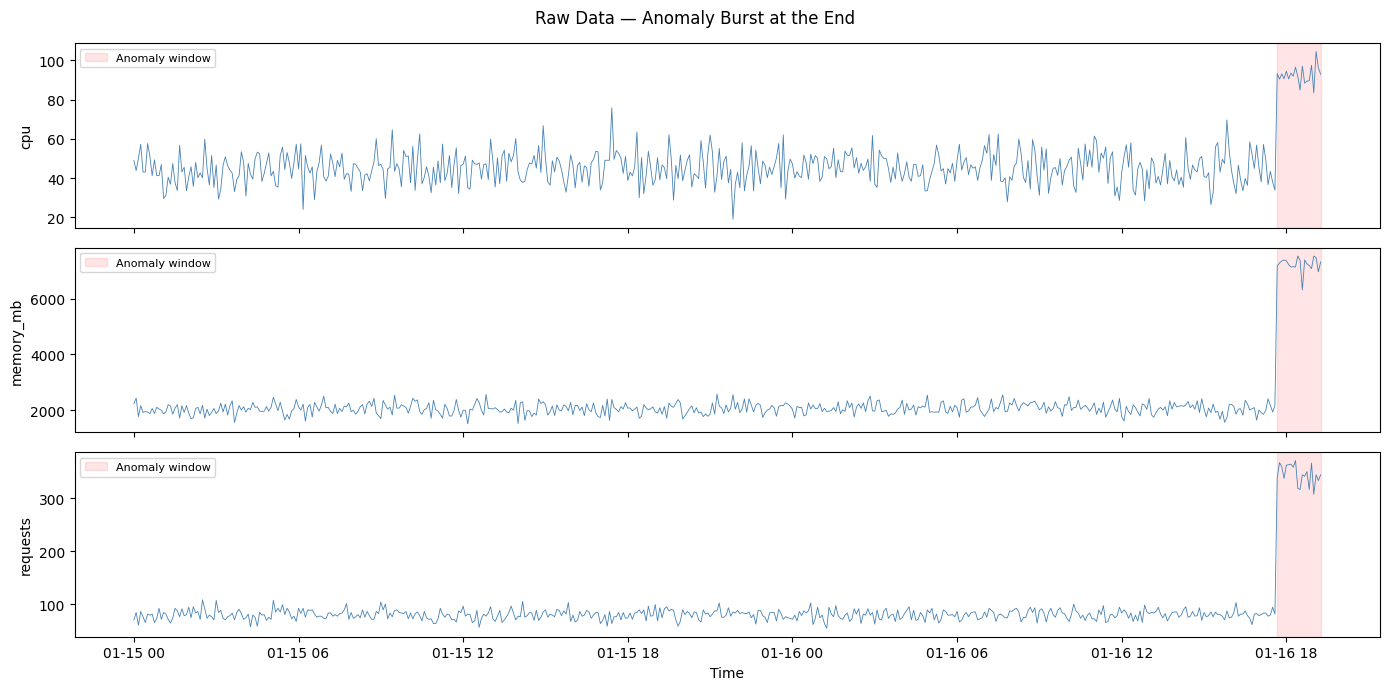

In [17]:
# Quick look at the raw data — the anomaly burst is visible at the end
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], linewidth=0.6, color='steelblue')
    ax.axvspan(df.index[n_normal], df.index[-1], color='red', alpha=0.1, label='Anomaly window')
    ax.set_ylabel(col)
    ax.legend(loc='upper left', fontsize=8)
axes[-1].set_xlabel('Time')
plt.suptitle('Raw Data — Anomaly Burst at the End')
plt.tight_layout()
plt.show()

---
## 2. Isolation Forest

The **Isolation Forest** algorithm detects anomalies by measuring how easy it is to "isolate" a data point. The intuition:
- Normal points are dense — they require many random splits to isolate
- Anomalies are sparse — they get isolated quickly with few splits

The `decision_function` returns a score where:
- **Negative values** → more anomalous (easier to isolate)
- **Positive values** → more normal (harder to isolate)
- The `contamination` parameter sets the expected fraction of anomalies, which determines the decision boundary.

In [18]:
iso = IsolationForestDetector(
    n_estimators=100,
    contamination=0.05,  # we expect ~5% anomalies
    random_state=42,
)

iso.fit(df)
preds = iso.predict(df)
scores = iso.decision_function(df)

n_detected = (preds == -1).sum()
print(f"Anomalies detected: {n_detected} / {n_total} ({n_detected/n_total*100:.1f}%)")
print(f"Score range: [{scores.min():.4f}, {scores.max():.4f}]")
print(f"Decision boundary: scores < 0 are flagged as anomalies")

Anomalies detected: 26 / 520 (5.0%)
Score range: [-0.1849, 0.2032]
Decision boundary: scores < 0 are flagged as anomalies


### Visualize with AnomalyVisualizer

We use Sentinel's `AnomalyVisualizer` to create both static (matplotlib) and interactive (plotly) views of the detection results.

The visualizer expects:
- A time-indexed DataFrame with a `scores` column and an `anomaly` column
- `anomaly = -1` for anomalies, `anomaly = 1` for normal points

In [19]:
# Prepare the DataFrame for AnomalyVisualizer
# We negate the scores so that higher = more anomalous (easier to read visually)
viz_df = pd.DataFrame({
    'scores': -scores,  # negate: higher = more anomalous
    'anomaly': preds,
}, index=df.index)

viz_df.head()

,scores,anomaly
2025-01-15 00:00:00,-0.165596,1
2025-01-15 00:05:00,-0.108943,1
2025-01-15 00:10:00,-0.036462,1
2025-01-15 00:15:00,-0.140634,1
2025-01-15 00:20:00,-0.180453,1


In [20]:
# Create an incidents DataFrame marking the true anomaly window
incidents_df = pd.DataFrame({
    'start_time': [df.index[n_normal]],
    'end_time': [df.index[-1]],
    'Servicio': ['Simulated CPU/Memory spike'],
})

viz = AnomalyVisualizer(
    anomaly_df=viz_df,
    incidents_df=incidents_df,
    score_col='scores',
    anomaly_col='anomaly',
)

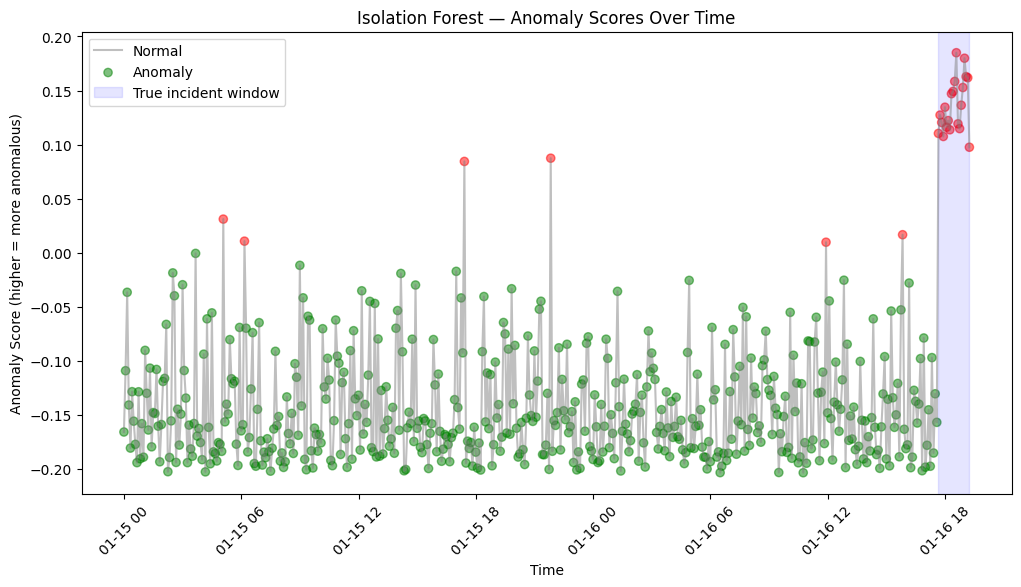

In [21]:
viz.plot_static(
    title='Isolation Forest — Anomaly Scores Over Time',
    xlabel='Time',
    ylabel='Anomaly Score (higher = more anomalous)',
    legend_labels=['Normal', 'Anomaly', 'True incident window'],
    colors={'normal': 'green', 'anomaly': 'red', 'incident': 'blue'},
)

### What we're observing

- **Green dots**: Normal samples with low anomaly scores — the detector considers these typical
- **Red dots**: Samples flagged as anomalies — their scores exceed the decision boundary
- **Blue shaded region**: The true incident window (last 20 samples) where we injected anomalies

If the red dots align well with the blue region, the detector is correctly identifying the anomalous period. Scattered red dots outside the blue region are **false positives**.

In [22]:
# Interactive view — hover over points to see exact scores and timestamps
viz.plot_dynamic(
    title='Isolation Forest — Interactive Anomaly Scores',
    xaxis_title='Time',
    yaxis_title='Anomaly Score',
    colors={'normal': 'steelblue', 'anomaly': 'crimson', 'incident': 'orange'},
)

### Zoomed view of the incident window

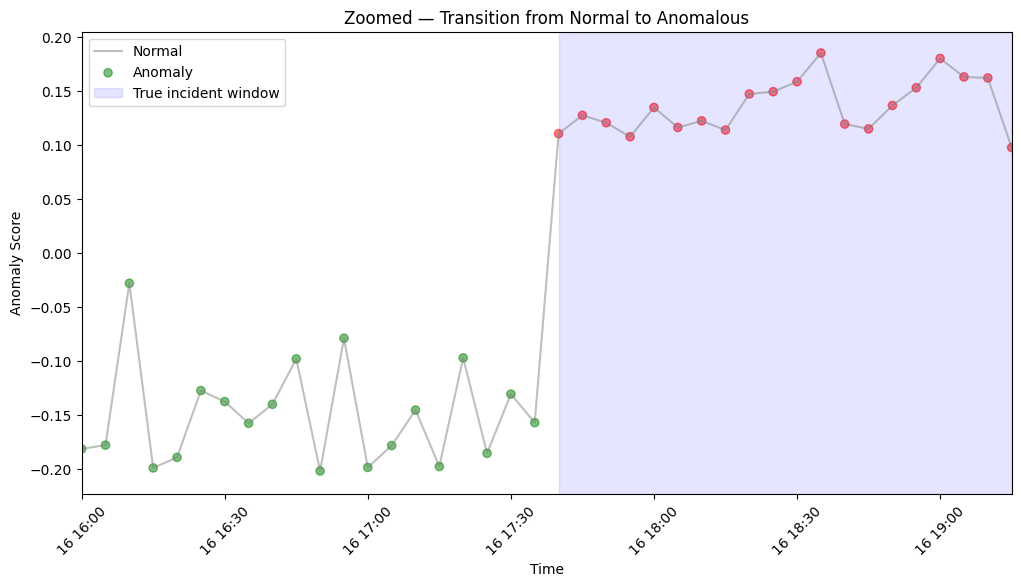

In [23]:
viz.plot_static(
    zoom=True,
    zoom_date=[str(df.index[n_normal - 20]), str(df.index[-1])],
    title='Zoomed — Transition from Normal to Anomalous',
    xlabel='Time',
    ylabel='Anomaly Score',
    legend_labels=['Normal', 'Anomaly', 'True incident window'],
)

---
## 3. Anomaly Probabilities

`predict_proba()` normalizes the decision function scores to a 0–1 range, where values closer to 1 indicate higher anomaly probability. This is useful when you need a confidence measure rather than a binary label.

In [24]:
proba = iso.predict_proba(df)

# Top 10 most anomalous
top_idx = np.argsort(proba)[-10:]
print("Top 10 most anomalous samples:\n")
for i in top_idx:
    true_label = 'ANOMALY' if labels_true[i] == -1 else 'normal'
    detected = '🔴' if preds[i] == -1 else '🟢'
    print(f"  {detected} idx={i:>3}, time={df.index[i]}, proba={proba[i]:.3f}, true={true_label}")

Top 10 most anomalous samples:

  🔴 idx=504, time=2025-01-16 18:00:00, proba=0.870, true=ANOMALY
  🔴 idx=514, time=2025-01-16 18:50:00, proba=0.875, true=ANOMALY
  🔴 idx=508, time=2025-01-16 18:20:00, proba=0.902, true=ANOMALY
  🔴 idx=509, time=2025-01-16 18:25:00, proba=0.908, true=ANOMALY
  🔴 idx=515, time=2025-01-16 18:55:00, proba=0.917, true=ANOMALY
  🔴 idx=510, time=2025-01-16 18:30:00, proba=0.932, true=ANOMALY
  🔴 idx=518, time=2025-01-16 19:10:00, proba=0.941, true=ANOMALY
  🔴 idx=517, time=2025-01-16 19:05:00, proba=0.943, true=ANOMALY
  🔴 idx=516, time=2025-01-16 19:00:00, proba=0.987, true=ANOMALY
  🔴 idx=511, time=2025-01-16 18:35:00, proba=1.000, true=ANOMALY


---
## 4. RRCF Detector

The **Robust Random Cut Forest** (RRCF) algorithm is designed for streaming anomaly detection on univariate time series. It builds an ensemble of random cut trees and measures each point's **Collusive Displacement (CoDisp)** — how much removing a point changes the tree structure.

- **High CoDisp** → the point significantly affects the tree → likely anomalous
- **Low CoDisp** → the point blends in → likely normal

Unlike Isolation Forest, RRCF works on 1D series and is naturally suited for streaming scenarios.

RRCF anomalies (>95th percentile): 26
Threshold: 10.0090


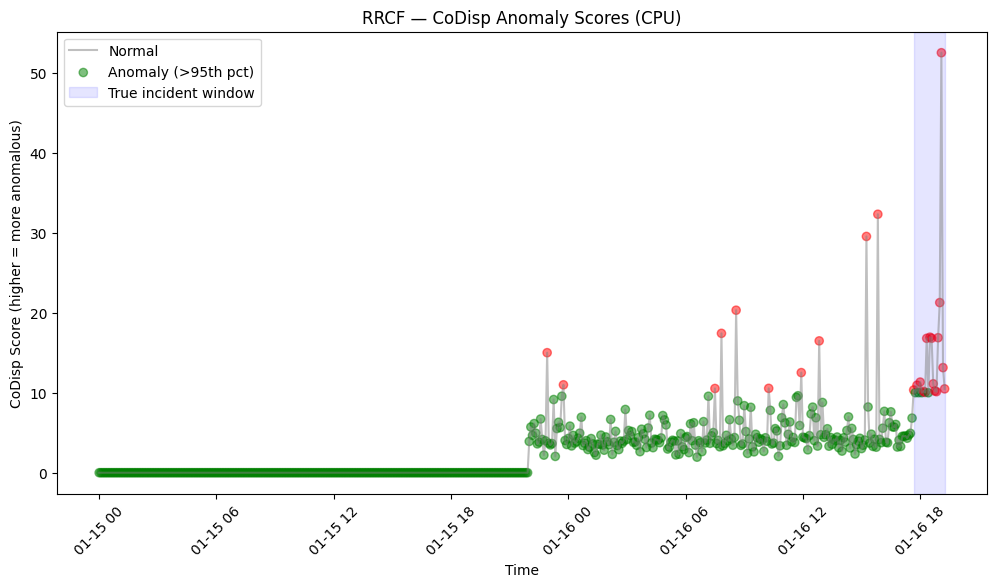

In [25]:
try:
    from sentinel.detectors import RRCFDetector

    # RRCF works on 1D series — we use the cpu column
    series = df['cpu'].reset_index(drop=True)
    rrcf_det = RRCFDetector(shingle_size=5, num_trees=50, tree_size=256)
    rrcf_scores = rrcf_det.fit_predict(series)

    # Determine threshold at 95th percentile
    threshold_95 = rrcf_scores.quantile(0.95)
    rrcf_anomalies = rrcf_det.get_anomalies(threshold_95)

    print(f"RRCF anomalies (>95th percentile): {len(rrcf_anomalies)}")
    print(f"Threshold: {threshold_95:.4f}")

    # Prepare for AnomalyVisualizer
    rrcf_viz_df = pd.DataFrame({
        'scores': rrcf_scores.values,
        'anomaly': np.where(rrcf_scores > threshold_95, -1, 1),
    }, index=df.index)

    rrcf_viz = AnomalyVisualizer(
        anomaly_df=rrcf_viz_df,
        incidents_df=incidents_df,
        score_col='scores',
        anomaly_col='anomaly',
    )

    rrcf_viz.plot_static(
        title='RRCF — CoDisp Anomaly Scores (CPU)',
        xlabel='Time',
        ylabel='CoDisp Score (higher = more anomalous)',
        legend_labels=['Normal', 'Anomaly (>95th pct)', 'True incident window'],
        colors={'normal': 'green', 'anomaly': 'red', 'incident': 'blue'},
    )

except ImportError:
    print("rrcf not installed. Install with: pip install rrcf")

### What we're observing

- The CoDisp scores are generally low during the normal period, with occasional small spikes (normal variance)
- During the anomaly window (blue region), scores spike dramatically because the CPU values are far from the learned distribution
- The 95th percentile threshold separates the bulk of normal scores from the anomalous ones

Note: RRCF is univariate — it only sees one feature at a time. For multivariate detection, use Isolation Forest or the deep learning detectors.

---
## 5. Custom Detector

You can build your own detector by extending `BaseCustomDetector`. The interface requires:
- `fit(X)` — learn the normal distribution
- `detect(X)` — return `(predictions, scores)`

Here we implement a simple Z-score detector: any sample where the maximum Z-score across features exceeds a threshold is flagged as anomalous.

In [26]:
class ZScoreDetector(BaseCustomDetector):
    """Z-score based anomaly detector.
    
    Flags samples where any feature's Z-score exceeds the threshold.
    """

    def __init__(self, threshold=3.0):
        super().__init__()
        self.threshold = threshold
        self.mean_ = None
        self.std_ = None

    def fit(self, X, y=None):
        X_arr = np.array(X)
        self.mean_ = np.mean(X_arr, axis=0)
        self.std_ = np.std(X_arr, axis=0)
        return self

    def predict(self, X):
        preds, _ = self.detect(X)
        return preds

    def detect(self, X):
        X_arr = np.array(X)
        z_scores = np.abs((X_arr - self.mean_) / self.std_)
        max_z = np.max(z_scores, axis=1)
        predictions = np.where(max_z > self.threshold, -1, 1)
        return predictions, max_z


zscore = ZScoreDetector(threshold=2.5)
zscore.fit(df)
z_preds, z_scores = zscore.detect(df)
print(f"Z-Score anomalies: {(z_preds == -1).sum()}")

Z-Score anomalies: 20


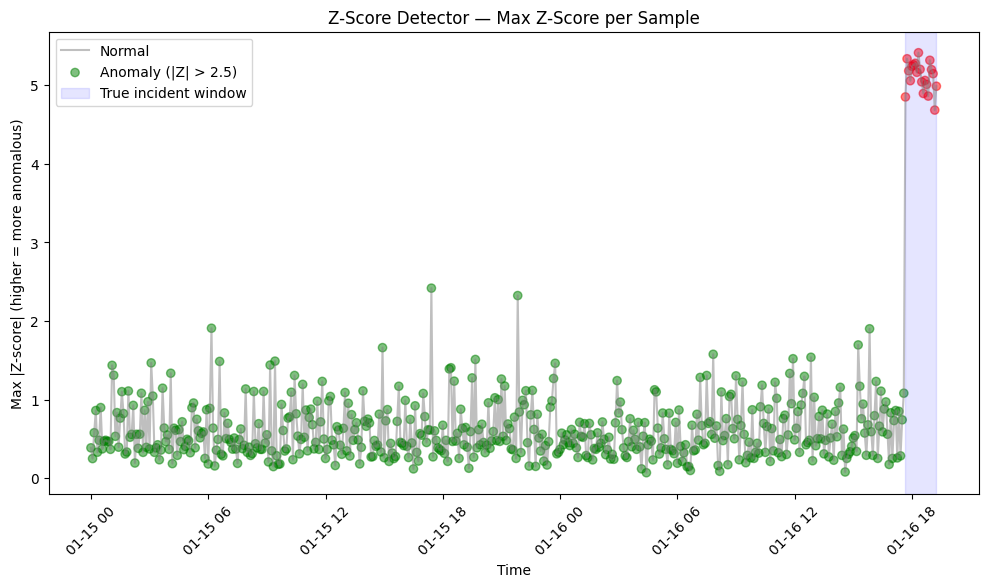

In [27]:
# Visualize Z-Score results with AnomalyVisualizer
z_viz_df = pd.DataFrame({
    'scores': z_scores,
    'anomaly': z_preds,
}, index=df.index)

z_viz = AnomalyVisualizer(
    anomaly_df=z_viz_df,
    incidents_df=incidents_df,
    score_col='scores',
    anomaly_col='anomaly',
)

z_viz.plot_static(
    title='Z-Score Detector — Max Z-Score per Sample',
    xlabel='Time',
    ylabel='Max |Z-score| (higher = more anomalous)',
    legend_labels=['Normal', 'Anomaly (|Z| > 2.5)', 'True incident window'],
    colors={'normal': 'green', 'anomaly': 'red', 'incident': 'blue'},
)

### What we're observing

- Normal samples have max Z-scores mostly below 2.5 (within ~2.5 standard deviations of the mean)
- Anomalous samples have Z-scores well above the threshold — the injected spike is 5+ standard deviations away
- The Z-score detector is simple but effective when anomalies are clearly separated in feature space

---
## 6. Detector Comparison

Let's compare all three detectors side by side to see how they perform on the same data.

In [28]:
# Accuracy metrics
def eval_detector(name, predictions, true_labels):
    tp = ((predictions == -1) & (true_labels == -1)).sum()
    fp = ((predictions == -1) & (true_labels == 1)).sum()
    fn = ((predictions == 1) & (true_labels == -1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {'detector': name, 'detected': (predictions == -1).sum(),
            'true_positives': tp, 'false_positives': fp,
            'precision': round(precision, 3), 'recall': round(recall, 3)}

comparison = [eval_detector('Isolation Forest', preds, labels_true),
              eval_detector('Z-Score (t=2.5)', z_preds, labels_true)]

try:
    rrcf_preds = np.where(rrcf_scores > threshold_95, -1, 1)
    comparison.append(eval_detector('RRCF (cpu only)', rrcf_preds, labels_true))
except NameError:
    pass

comp_df = pd.DataFrame(comparison).set_index('detector')
comp_df

,detected,true_positives,false_positives,precision,recall
detector,,,,,
Isolation Forest,26,20,6,0.769,1.0
Z-Score (t=2.5),20,20,0,1.000,1.0
RRCF (cpu only),26,16,10,0.615,0.8


### How to read the comparison

| Metric | Meaning |
|--------|---------|
| `detected` | Total samples flagged as anomalies |
| `true_positives` | Correctly identified anomalies |
| `false_positives` | Normal samples incorrectly flagged |
| `precision` | Of all flagged samples, how many are truly anomalous? (higher = fewer false alarms) |
| `recall` | Of all true anomalies, how many were caught? (higher = fewer missed anomalies) |

The ideal detector has high precision AND high recall. In practice, there's a trade-off:
- Lower `contamination` / higher threshold → fewer false positives but may miss subtle anomalies
- Higher `contamination` / lower threshold → catches more anomalies but more false alarms

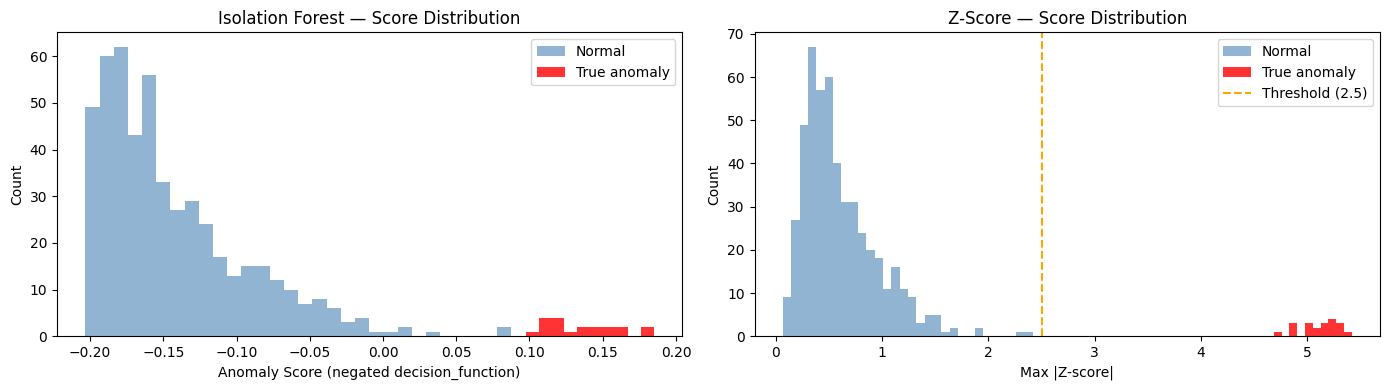

In [29]:
# Visual comparison of score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Isolation Forest scores
axes[0].hist(-scores[labels_true == 1], bins=30, alpha=0.6, label='Normal', color='steelblue')
axes[0].hist(-scores[labels_true == -1], bins=10, alpha=0.8, label='True anomaly', color='red')
axes[0].set_xlabel('Anomaly Score (negated decision_function)')
axes[0].set_ylabel('Count')
axes[0].set_title('Isolation Forest — Score Distribution')
axes[0].legend()

# Z-Score
axes[1].hist(z_scores[labels_true == 1], bins=30, alpha=0.6, label='Normal', color='steelblue')
axes[1].hist(z_scores[labels_true == -1], bins=10, alpha=0.8, label='True anomaly', color='red')
axes[1].axvline(2.5, color='orange', linestyle='--', label='Threshold (2.5)')
axes[1].set_xlabel('Max |Z-score|')
axes[1].set_ylabel('Count')
axes[1].set_title('Z-Score — Score Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

### What we're observing

The histograms show the **separation** between normal and anomalous score distributions:
- Good separation (little overlap) → the detector can reliably distinguish anomalies
- Poor separation (heavy overlap) → the detector will produce many false positives or miss anomalies

Both detectors show clear separation here because the injected anomalies are far from the normal distribution. With subtler anomalies, you'd see more overlap and would need to tune thresholds more carefully.

---
## Summary

| Detector | Strengths | Limitations |
|----------|-----------|-------------|
| `IsolationForestDetector` | Multivariate, robust, no distribution assumptions | Batch-only, `contamination` must be estimated |
| `RRCFDetector` | Streaming-friendly, no contamination parameter | Univariate only, slower on large datasets |
| Custom (Z-Score) | Simple, interpretable, fast | Assumes normality, sensitive to outliers in training data |

Use `AnomalyVisualizer` to inspect results visually — both static plots for reports and interactive plots for exploration. For deep learning detectors, see notebook 05.